# Sorting Data on GPU

Sorting is the backbone of both intraday and EOD workflows, and is where the KDB-X GPU Acceleration really shines.
Two approaches are available depending on whether you need the full sorted result or just the top-N rows.
In this tutorial, we demonstrate sorting data both in-memory and on-disk.

## Setup

This notebook is compatible with Linux, Mac, and Windows via WSL.

This notebook is designed to be run as a Python notebook, but the same functionality can be applied directly in a CLI with KDB-X (given it's running on a KDB-X CUDA application environment).
If running `q` from the terminal, just copy the `q` code and paste into your terminal.

We first want to use our `gentab.q` script to create some order data and write this to disk.
This will manually write the splay table column by column in order to save on memory, however the save effect can be acheived by manually creating the full table in memory and writing to disk using `set`.
For the sake of this tutorial, we use `gentab.q` to easily generate sample data in order to showcase performance improvements when using the `gpu` module against a large dataset.

In [1]:
## Initial imports
import pykx as kx
import matplotlib.pyplot as plt

In [2]:
%%q
\l src/gentab.q

// This may take a while to generate all data and write to disk
gentab[`:/app/example/db/orders10m/;10000000];
gentab[`:/app/example/db/orders20m/;20000000];
gentab[`:/app/example/db/orders30m/;30000000];
gentab[`:/app/example/db/orders40m/;40000000];
gentab[`:/app/example/db/orders50m/;50000000];

Writing .d file
Writing col orderId to :/app/example/db/orders10m//orderId
Writing col productId to :/app/example/db/orders10m//productId
Writing col time to :/app/example/db/orders10m//time
Writing col pubTime to :/app/example/db/orders10m//pubTime
Writing col accId to :/app/example/db/orders10m//accId
Writing col analyticId to :/app/example/db/orders10m//analyticId
Writing col analyticDataType to :/app/example/db/orders10m//analyticDataType
Writing col doubleValue to :/app/example/db/orders10m//doubleValue
Writing col stringValue to :/app/example/db/orders10m//stringValue
Writing col processPre to :/app/example/db/orders10m//processPre
Writing col processSuf to :/app/example/db/orders10m//processSuf
Writing col orderKey to :/app/example/db/orders10m//orderKey
Writing .d file
Writing col orderId to :/app/example/db/orders20m//orderId
Writing col productId to :/app/example/db/orders20m//productId
Writing col time to :/app/example/db/orders20m//time
Writing col pubTime to :/app/example/

## In-memory sort with `.gpu.iasc`

In-memory sorting can be achieved using `.gpu.iasc`:

```q
.gpu.iasc[t]
```
where
- t is a table on gpu

The return is an on gpu list of indexes given by sorting the table lexiocraphically based on column order.
To achieve a round trip from cpu we can do:

```q
.gpu.from .gpu.iasc .gpu.to table
```

Below is an example of how to use this functionality on disk:

In [3]:
kx.q("\\s")

pykx.IntAtom(pykx.q('48i'))

In [ ]:
kx.IntAtom(kx.q('48i'))

pykx.IntAtom(pykx.q('48i'))

Let's now enable our `gpu` module, load in the example data above, and run some benchmarks for in-memory sorting on CPU vs. GPU:

In [3]:
%%q
.gpu:use`kx.gpu

// Load in our example data
\l /app/example/db

// Benchmark for in-memory sorting of our tables comparing CPU vs. GPU performance
inMemSort:(`$string[l])!{T:.gpu.to t:?[`$"orders",string[x],"m";();0b;c!c:`orderId`time];
                tt1:.z.p;iasc t;tt1:.z.p-tt1;                           // sort on cpu
                tt2:.z.p;.gpu.iasc T;tt2:.z.p-tt2;                      // sort on gpu
                tt3:.z.p;.gpu.from .gpu.iasc .gpu.to t;tt3:.z.p-tt3;    // round-trip sort on gpu
                (tt1;tt2;tt3)} each l:10 20 30 40 50

### In-memory sort, GPU is winning

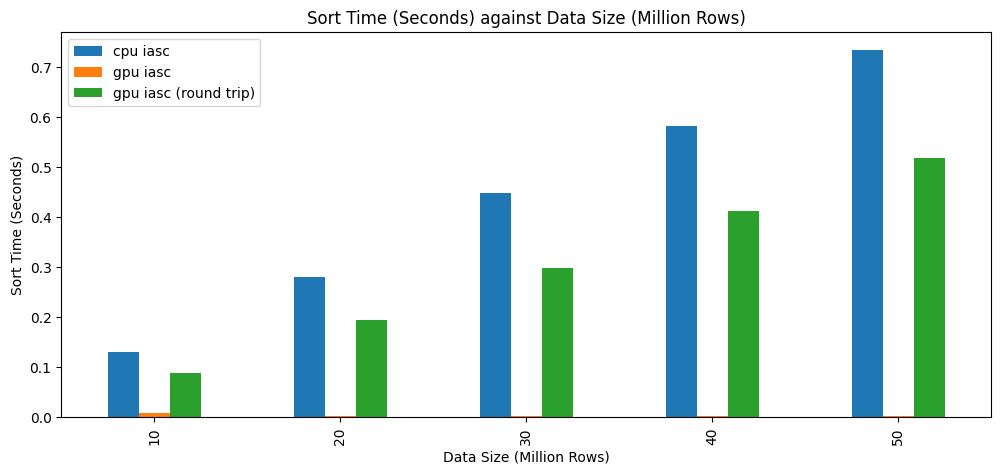

In [4]:
kx.q('flip 1e-9*"j"$inMemSort').pd().T.plot(kind="bar",figsize=(12,5),title="Sort Time (Seconds) against Data Size (Million Rows)")
plt.xlabel("Data Size (Million Rows)")
plt.ylabel("Sort Time (Seconds)")
plt.legend(["cpu iasc","gpu iasc","gpu iasc (round trip)"])
plt.show()

## Full table sort with `.gpu.xasc`

We can extend this a bit further to showcase a full table sort on-disk:

In [5]:
%%q
\d .sort

// helper functions
eq:{[d;c;j;i](=;c[i];d[i;j])}
start:{[j;d;c]({[d;c;j](eq[d;c;0] each til j),enlist[(<;c[j];d[j;0])]}[d;c]each til j+1),enlist (eq[d;c;0] each til j), enlist (&;(>=;c[j];d[j;0]);(<;c[j];d[j;1]))}
end:{[j;d;c]n:count flip d;enlist[(eq[d;c;n-2] each til j), enlist[(>=;c[j];d[j;n-1])]],({[d;c;j;n] (eq[d;c;n-2] each til j) ,enlist[(>;c[j];d[j;n-1])] }[d;c;;n] each reverse til j)};
stepipk:{[i;k;j;d;c] ({[d;c;j;I;i](eq[d;c;j]each til I+i+1),enlist(<;c[I+i+1];d[I+i+1;j])}[d;c;j;i] each til k-i),enlist (eq[d;c;j] each til k),enlist (&;(>=;c[k];d[k;j]);(<;c[k];d[k;j+1]))}
stepimk:{[i;k;j;d;c] enlist[({[d;c;j;i](=;c[i];d[i;j])}[d;c;j]each til i),enlist[(>=;c[i];d[i;j])]],({[d;c;j;I;i](eq[d;c;j]each til I-i+1),enlist ((>;c[I-i+1];d[I-i+1;j+1]))}[d;c;j;i] each til i-k+1), enlist (eq[d;c;j]each til k),enlist (&;(>;c[k];d[k;j]);(<;c[k];d[k;j+1]))   }
step:{$[0<=x[1]-x[0];stepipk[x[0];x[1]];stepimk[x[0];x[1]]]}
flipper:{$[type[x]in 11 20h;enlist each value x;x]}
statbatches:{ [t;c;M] labels:c,`xabcdefg;
		      L:asc (1000*M)?count[t];
		      a:labels xasc ?[t;enlist (in;`i;L);0b;labels!rc:c,`i];
		      d:value flip a floor count[a]*(1%M)*1+til M-1;
		      l:first each where each flip d <> next each d;
		      funcs:(start,step each -1_flip (-1_l;1_l)),end;
		      raze {z[0][z[1];x;y]}[flipper each d;rc] each flip (funcs;l[0],(1+til count[funcs]-2),last[-1_l])}

writebatch:{[x;o;y]
	upsert[o]each x
	}

sortsingle:{[c;t;x]
		.gpu.sdev[x[0]];
		fromdisk:?[d:?[t;x[1];0b;()];();0b;c!c];
		gputab:.gpu.to fromdisk;
		f:.gpu.iasc gputab;
		a:d@.gpu.from f;
		a}

// full service GPU sort function
.gpu.sort.xasc:{[c;t;o]

	// ensure data fits on GPUs 
	sizeData:sum hcount each `$string[t],/:string c;
	sizeGPU:min{.gpu.sdev[x];first .gpu.mdev[]}each til .gpu.ndev[];
	batchesGPU:ceiling 3*sizeData%sizeGPU;

	// ensure data fits on CPU
	sizeData:sum hcount each `$string[t],/:string cols get t;
	sizeCPU:(.Q.w[][`mphy])-.Q.w[][`heap];
	batchesCPU:ceiling 2*sizeData%sizeCPU%2*.gpu.ndev[];

	batches:statbatches[get t;c;max(3;batchesGPU;batchesCPU)];

	// function to upsert batches
	w:writebatch[;o;];

	// function to sort batches on multiple gpus
	s:{[x;t;c;y]
		sortsingle[c;t] peach flip(til count x;x)}[;t;c;];

	// main routine
	res:{[w;s;x;y]a:{x`}peach(w[x];s[y]);a 1}[w;s]/[();.gpu.ndev[]cut batches];
	upsert[o]each res;
	.Q.gc[];
  }

In [ ]:
%%q
// Sorting all data on disk will take a while to fully execute
onDiskSort:(`$string[l])!{
                t:.z.p;.gpu.sort.xasc[`orderId`time;`$":/app/example/db/orders",string[x],"m/";`$":/app/example/db/sorder",string[x],"m/"];t:.z.p-t;
                tt:.z.p;xasc[`orderId`time;`$":/app/example/db/orders",string[x],"m/"];
                (t;.z.p-tt)} each l:10 20 30 40 50

### On-disk sort - times are bottlenecked by disk I/O, but GPU is still winning as data volume increases

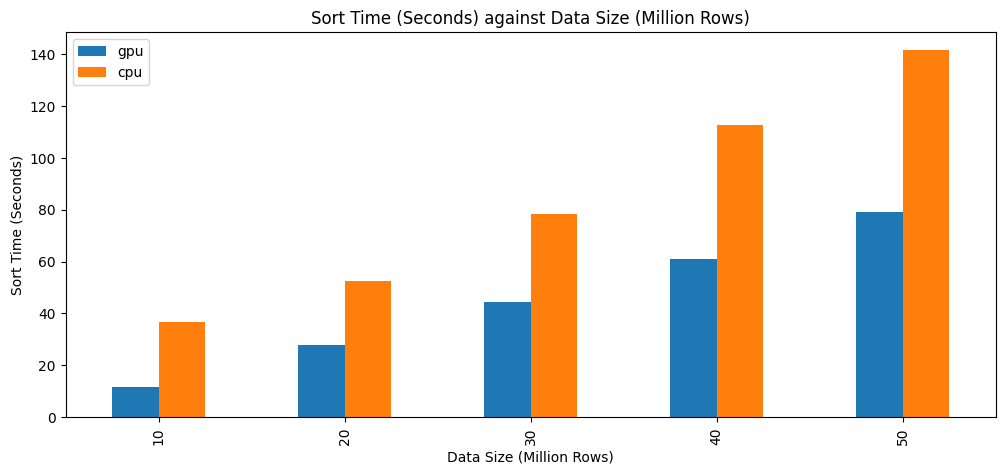

In [7]:
kx.q('flip 1e-9*"j"$onDiskSort').pd().T.plot(kind="bar",figsize=(12,5),title="Sort Time (Seconds) against Data Size (Million Rows)")
plt.xlabel("Data Size (Million Rows)")
plt.ylabel("Sort Time (Seconds)")
plt.legend(["gpu","cpu"])
plt.show()